In [1]:
set.seed(405)
options(stringsAsFactors = FALSE)

In [2]:
required_packages <- c("rstan", "dplyr", "readr", "tibble", "stringr", "tidyr", "ggplot2")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) install.packages(missing_packages, repos = "https://cloud.r-project.org")
invisible(lapply(required_packages, library, character.only = TRUE))
rstan_options(auto_write = TRUE)
options(mc.cores = parallel::detectCores())

Loading required package: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”

Attaching package: ‘tidyr’


The following object is masked from ‘package:rstan’:

    extract


Warning message:
“package ‘ggplot

In [3]:
model_tbl <- readr::read_csv("../output/derived/gss_2024_model_table.csv", show_col_types = FALSE) %>%
  dplyr::mutate(
    degree = as.factor(degree),
    sex = as.factor(sex),
    region = as.factor(region),
    polviews_bin = factor(polviews_bin, levels = c("Liberal", "Moderate", "Conservative"))
  )

In [4]:
m1_tbl <- model_tbl %>%
  dplyr::filter(!is.na(confinan_ord), !is.na(polviews), !is.na(age_std), !is.na(income_std), !is.na(degree), !is.na(sex), !is.na(region))
X_m1 <- stats::model.matrix(~ polviews + age_std + income_std + degree + sex + region, data = m1_tbl)
X_m1 <- X_m1[, colnames(X_m1) != "(Intercept)", drop = FALSE]
y_m1 <- as.integer(m1_tbl$confinan_ord)

m2_tbl <- model_tbl %>%
  dplyr::filter(!is.na(confinan_ord), !is.na(polviews_bin), !is.na(age_std), !is.na(income_std), !is.na(degree), !is.na(sex), !is.na(region))
X_m2 <- stats::model.matrix(~ age_std + income_std + degree + sex + region, data = m2_tbl)
X_m2 <- X_m2[, colnames(X_m2) != "(Intercept)", drop = FALSE]
y_m2 <- as.integer(m2_tbl$confinan_ord)
ideology_id <- as.integer(m2_tbl$polviews_bin)

stan_data_m1 <- list(N = nrow(X_m1), K = ncol(X_m1), y = y_m1, X = X_m1)
stan_data_m2 <- list(N = nrow(X_m2), K = ncol(X_m2), G = length(levels(m2_tbl$polviews_bin)), y = y_m2, X = X_m2, ideology_id = ideology_id)

tibble::tibble(metric = c("m1_N", "m1_K", "m2_N", "m2_K", "m2_G"), value = c(stan_data_m1$N, stan_data_m1$K, stan_data_m2$N, stan_data_m2$K, stan_data_m2$G))

metric,value
<chr>,<int>
m1_N,2223
m1_K,11
m2_N,2223
m2_K,10
m2_G,3


In [5]:
run_sensitivity <- function(model_label, prior_label, prior_beta_sd, prior_c_sd, prior_mu_sd, prior_sigma_sd, data_list) {
  if (model_label == "Model1") {
    code <- paste0(
      "data { int<lower=1> N; int<lower=1> K; int<lower=1,upper=3> y[N]; matrix[N,K] X; }
",
      "parameters { vector[K] beta; ordered[2] c; }
",
      "model { beta ~ normal(0, ", prior_beta_sd, " ); c ~ normal(0, ", prior_c_sd, " ); y ~ ordered_logistic(X * beta, c); }"
    )
  } else {
    code <- paste0(
      "data { int<lower=1> N; int<lower=1> K; int<lower=1> G; int<lower=1,upper=3> y[N]; matrix[N,K] X; int<lower=1,upper=G> ideology_id[N]; }
",
      "parameters { vector[K] beta; ordered[2] c; real mu_alpha; real<lower=0> sigma_alpha; vector[G] z_alpha; }
",
      "transformed parameters { vector[G] alpha; alpha = mu_alpha + sigma_alpha * z_alpha; }
",
      "model { beta ~ normal(0, ", prior_beta_sd, " ); c ~ normal(0, ", prior_c_sd, " ); mu_alpha ~ normal(0, ", prior_mu_sd, " ); sigma_alpha ~ normal(0, ", prior_sigma_sd, " ); z_alpha ~ normal(0,1); for (n in 1:N) y[n] ~ ordered_logistic(alpha[ideology_id[n]] + X[n] * beta, c); }"
    )
  }

  sm <- rstan::stan_model(model_code = code)
  fit <- rstan::sampling(
    object = sm,
    data = data_list,
    chains = 2,
    iter = 1200,
    warmup = 600,
    seed = 405,
    refresh = 0,
    control = list(adapt_delta = 0.9)
  )

  summ <- as.data.frame(rstan::summary(fit)$summary, check.names = FALSE)
  summ$parameter <- rownames(summ)
  summ <- summ %>% dplyr::relocate(parameter)

  key_params <- if (model_label == "Model1") {
    c("beta[1]", "beta[2]", "c[1]", "c[2]")
  } else {
    c("mu_alpha", "sigma_alpha", "alpha[1]", "alpha[2]", "alpha[3]")
  }

  out <- summ %>%
    dplyr::filter(parameter %in% key_params) %>%
    dplyr::select(parameter, mean, sd, `2.5%`, `50%`, `97.5%`, Rhat) %>%
    dplyr::mutate(model = model_label, prior = prior_label, .before = parameter)

  sampler_params <- rstan::get_sampler_params(fit, inc_warmup = FALSE)
  n_div <- sum(vapply(sampler_params, function(x) sum(x[, "divergent__"]), numeric(1)))

  diag <- tibble::tibble(
    model = model_label,
    prior = prior_label,
    max_rhat = max(out$Rhat, na.rm = TRUE),
    n_divergences = n_div
  )

  list(summary = out, diag = diag)
}

prior_specs <- tibble::tribble(
  ~prior, ~beta_sd, ~c_sd, ~mu_sd, ~sigma_sd,
  "tight", 0.5, 1.5, 0.5, 0.5,
  "wide", 2.0, 5.0, 2.0, 2.0
)
prior_specs

prior,beta_sd,c_sd,mu_sd,sigma_sd
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
tight,0.5,1.5,0.5,0.5
wide,2.0,5.0,2.0,2.0


In [6]:
m1_results <- lapply(seq_len(nrow(prior_specs)), function(i) {
  run_sensitivity(
    model_label = "Model1",
    prior_label = prior_specs$prior[i],
    prior_beta_sd = prior_specs$beta_sd[i],
    prior_c_sd = prior_specs$c_sd[i],
    prior_mu_sd = prior_specs$mu_sd[i],
    prior_sigma_sd = prior_specs$sigma_sd[i],
    data_list = stan_data_m1
  )
})

m2_results <- lapply(seq_len(nrow(prior_specs)), function(i) {
  run_sensitivity(
    model_label = "Model2",
    prior_label = prior_specs$prior[i],
    prior_beta_sd = prior_specs$beta_sd[i],
    prior_c_sd = prior_specs$c_sd[i],
    prior_mu_sd = prior_specs$mu_sd[i],
    prior_sigma_sd = prior_specs$sigma_sd[i],
    data_list = stan_data_m2
  )
})

sensitivity_summary <- dplyr::bind_rows(lapply(c(m1_results, m2_results), function(x) x$summary))
sensitivity_diag <- dplyr::bind_rows(lapply(c(m1_results, m2_results), function(x) x$diag))

list(nrow(sensitivity_summary), nrow(sensitivity_diag))

Warning message:
“Bulk Effective Samples Size (ESS) is too low, indicating posterior means and medians may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#bulk-ess”


[[1]]
[1] 18

[[2]]
[1] 4

In [7]:
baseline_m1 <- readr::read_csv("../output/model1_nuts/fit_summary.csv", show_col_types = FALSE) %>%
  dplyr::filter(parameter %in% c("beta[1]", "beta[2]", "c[1]", "c[2]")) %>%
  dplyr::select(parameter, base_mean = mean, base_sd = sd) %>%
  dplyr::mutate(model = "Model1")

baseline_m2 <- readr::read_csv("../output/model2_nuts/fit_summary.csv", show_col_types = FALSE) %>%
  dplyr::filter(parameter %in% c("mu_alpha", "sigma_alpha", "alpha[1]", "alpha[2]", "alpha[3]")) %>%
  dplyr::select(parameter, base_mean = mean, base_sd = sd) %>%
  dplyr::mutate(model = "Model2")

baseline_key <- dplyr::bind_rows(baseline_m1, baseline_m2)

sensitivity_vs_baseline <- sensitivity_summary %>%
  dplyr::left_join(baseline_key, by = c("model", "parameter")) %>%
  dplyr::mutate(
    abs_mean_shift = abs(mean - base_mean),
    sd_ratio_vs_base = sd / base_sd
  ) %>%
  dplyr::arrange(model, parameter, prior)

sensitivity_metrics <- sensitivity_vs_baseline %>%
  dplyr::group_by(model, prior) %>%
  dplyr::summarise(
    median_abs_mean_shift = stats::median(abs_mean_shift, na.rm = TRUE),
    median_sd_ratio_vs_base = stats::median(sd_ratio_vs_base, na.rm = TRUE),
    .groups = "drop"
  )

sensitivity_metrics

model,prior,median_abs_mean_shift,median_sd_ratio_vs_base
<chr>,<chr>,<dbl>,<dbl>
Model1,tight,0.004932717,0.9501399
Model1,wide,0.013860246,1.0380343
Model2,tight,0.039008226,0.5407606
Model2,wide,0.047961679,2.1033794


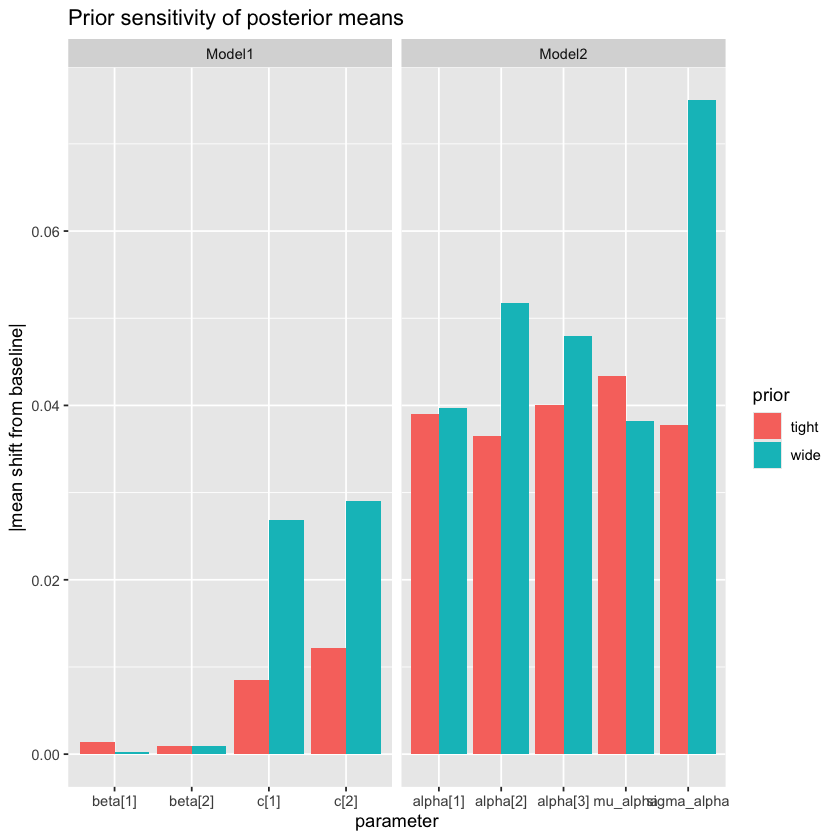

In [8]:
p_shift <- ggplot2::ggplot(sensitivity_vs_baseline, ggplot2::aes(x = parameter, y = abs_mean_shift, fill = prior)) +
  ggplot2::geom_col(position = "dodge") +
  ggplot2::facet_wrap(~ model, scales = "free_x") +
  ggplot2::labs(x = "parameter", y = "|mean shift from baseline|", title = "Prior sensitivity of posterior means")

p_sd <- ggplot2::ggplot(sensitivity_vs_baseline, ggplot2::aes(x = parameter, y = sd_ratio_vs_base, fill = prior)) +
  ggplot2::geom_col(position = "dodge") +
  ggplot2::geom_hline(yintercept = 1, linetype = "dashed") +
  ggplot2::facet_wrap(~ model, scales = "free_x") +
  ggplot2::labs(x = "parameter", y = "sd ratio vs baseline", title = "Prior sensitivity of posterior uncertainty")

p_shift

In [9]:
dir.create("../output/sensitivity", recursive = TRUE, showWarnings = FALSE)
readr::write_csv(sensitivity_summary, "../output/sensitivity/sensitivity_summary.csv")
readr::write_csv(sensitivity_diag, "../output/sensitivity/sensitivity_diagnostics.csv")
readr::write_csv(sensitivity_vs_baseline, "../output/sensitivity/sensitivity_vs_baseline.csv")
readr::write_csv(sensitivity_metrics, "../output/sensitivity/sensitivity_metrics.csv")
ggplot2::ggsave(filename = "../output/sensitivity/prior_mean_shift.png", plot = p_shift, width = 8, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/sensitivity/prior_sd_ratio.png", plot = p_sd, width = 8, height = 4.5, dpi = 150)